In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [10]:
customers = pd.read_csv(r"C:\Data Analusis Course\week12\customers-1.csv")
products = pd.read_csv(r"C:\Data Analusis Course\week12\products.csv")
sales = pd.read_csv(r"C:\Data Analusis Course\week12\sales.csv")


In [11]:
sales['transaction_date'] = pd.to_datetime(sales['transaction_date'])
sales['day_name'] = sales['transaction_date'].dt.day_name()

# Merge datasets for comprehensive analysis
df = sales.merge(customers, on='customer_id', how='left')
df = df.merge(products, on='product_id', how='left')

# Calculate total revenue per transaction
df['revenue'] = df['quantity'] * df['price']

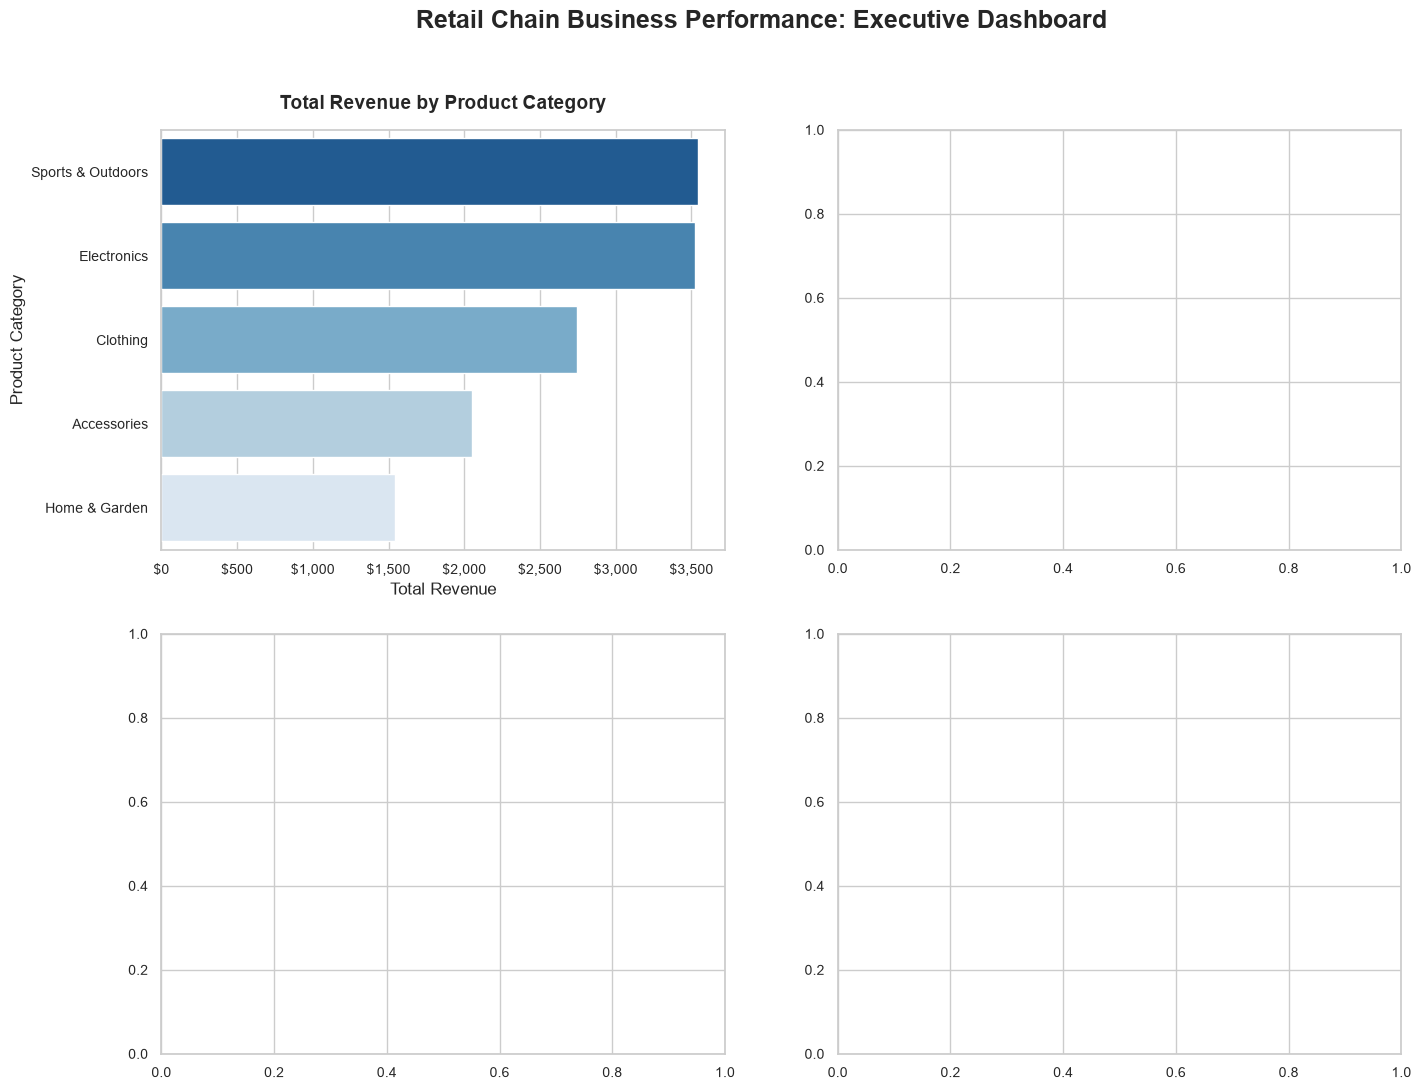

In [15]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 18
})
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retail Chain Business Performance: Executive Dashboard', fontweight='bold', y=0.98)

ax1 = axes[0, 0]
rev_by_cat = df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()

sns.barplot(
    x='revenue', y='category', data=rev_by_cat, 
    ax=ax1, palette='Blues_r', hue='category', legend=False
)
ax1.set_title('Total Revenue by Product Category', fontweight='bold', pad=15)
ax1.set_xlabel('Total Revenue')
ax1.set_ylabel('Product Category')
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

Text(0, 0.5, 'State')

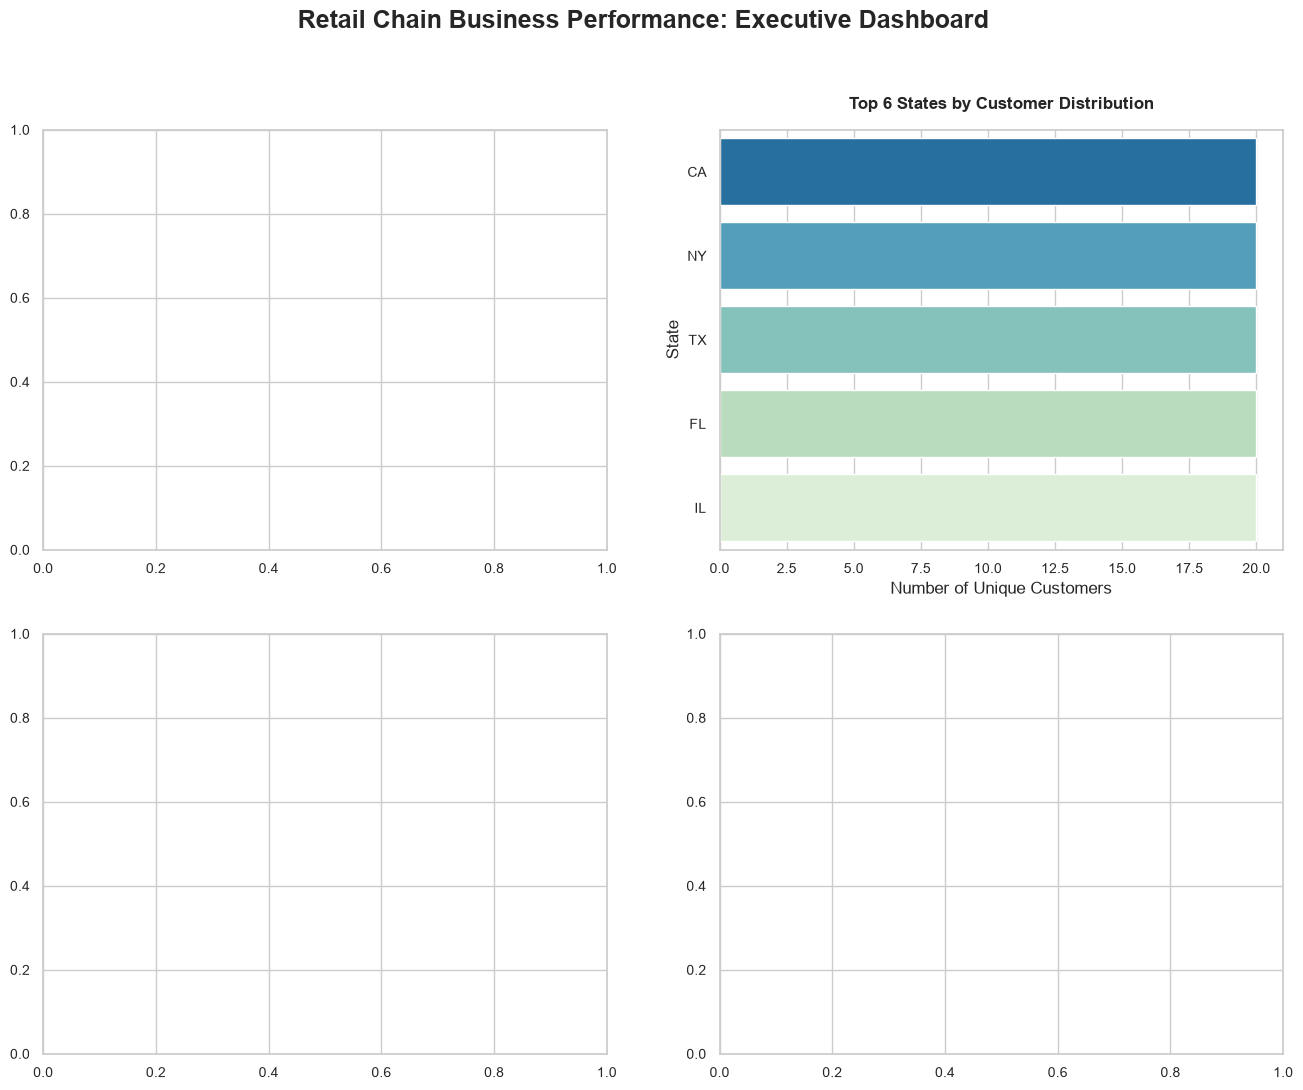

In [28]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 18
})
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retail Chain Business Performance: Executive Dashboard', fontweight='bold', y=0.98)
sns.set_theme(style="whitegrid")

ax2 = axes[0, 1]
top_states = customers['state'].value_counts().head(6).reset_index()
top_states.columns = ['state', 'customer_count']

sns.barplot(
    x='customer_count', y='state', data=top_states, 
    ax=ax2, palette='GnBu_r', hue='state', legend=False
)
ax2.set_title('Top 6 States by Customer Distribution', fontweight='bold', pad=15)
ax2.set_xlabel('Number of Unique Customers')
ax2.set_ylabel('State')


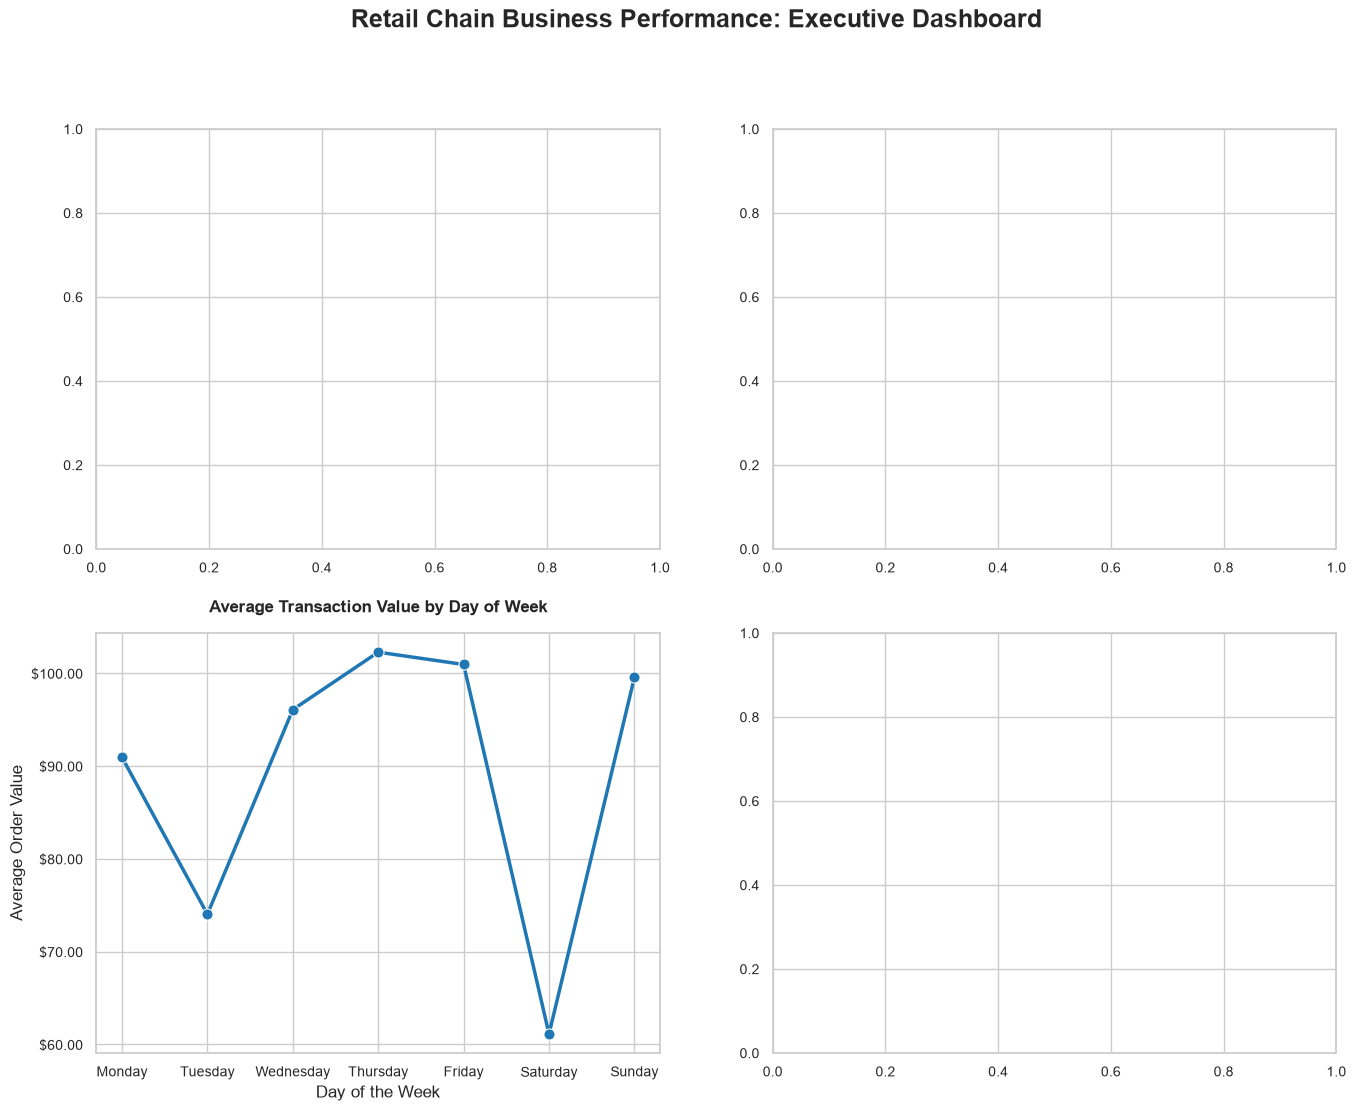

In [27]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 18
})
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retail Chain Business Performance: Executive Dashboard', fontweight='bold', y=0.98)
sns.set_theme(style="whitegrid")

ax3 = axes[1, 0]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_name')['revenue'].mean().reindex(day_order).reset_index()

sns.lineplot(
    x='day_name', y='revenue', data=daily_avg, 
    ax=ax3, marker='o', markersize=8, color='#1f77b4', linewidth=2.5
)
ax3.set_title('Average Transaction Value by Day of Week', fontweight='bold', pad=15)
ax3.set_xlabel('Day of the Week')
ax3.set_ylabel('Average Order Value')
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.2f}'))

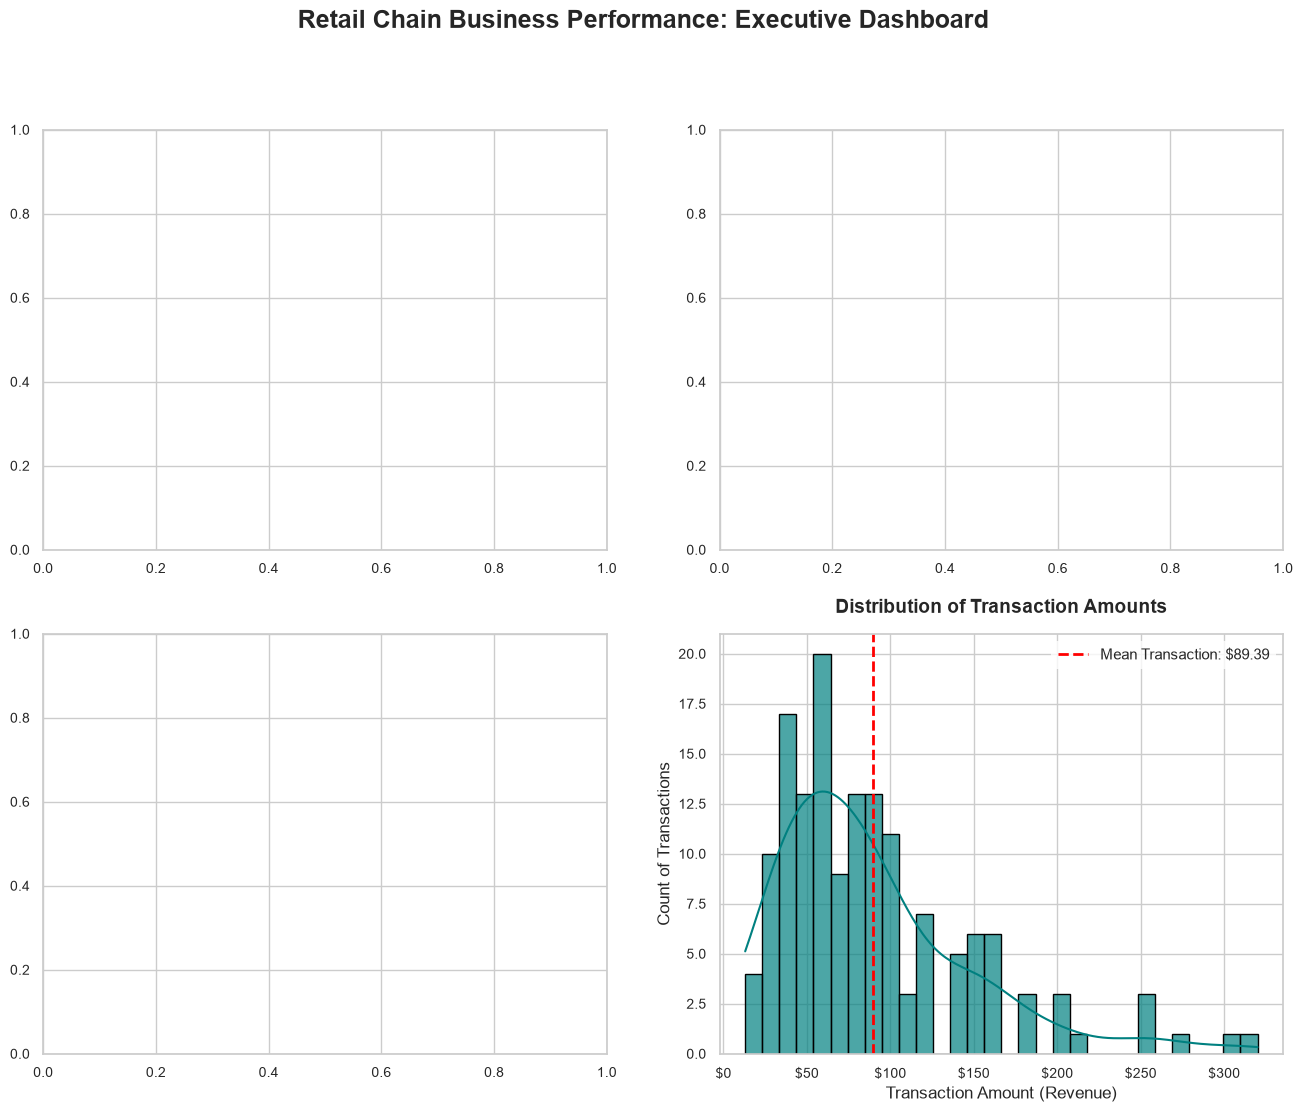

In [26]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 18
})
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retail Chain Business Performance: Executive Dashboard', fontweight='bold', y=0.98)

ax4 = axes[1, 1]
mean_val = df['revenue'].mean()

sns.histplot(
    df['revenue'], bins=30, ax=ax4, 
    kde=True, color='teal', edgecolor='black', alpha=0.7
)
ax4.axvline(
    mean_val, color='red', linestyle='--', 
    linewidth=2, label=f'Mean Transaction: ${mean_val:.2f}'
)
ax4.set_title('Distribution of Transaction Amounts', fontweight='bold', pad=15)
ax4.set_xlabel('Transaction Amount (Revenue)')
ax4.set_ylabel('Count of Transactions')
ax4.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax4.legend(frameon=True, facecolor='white', edgecolor='none')

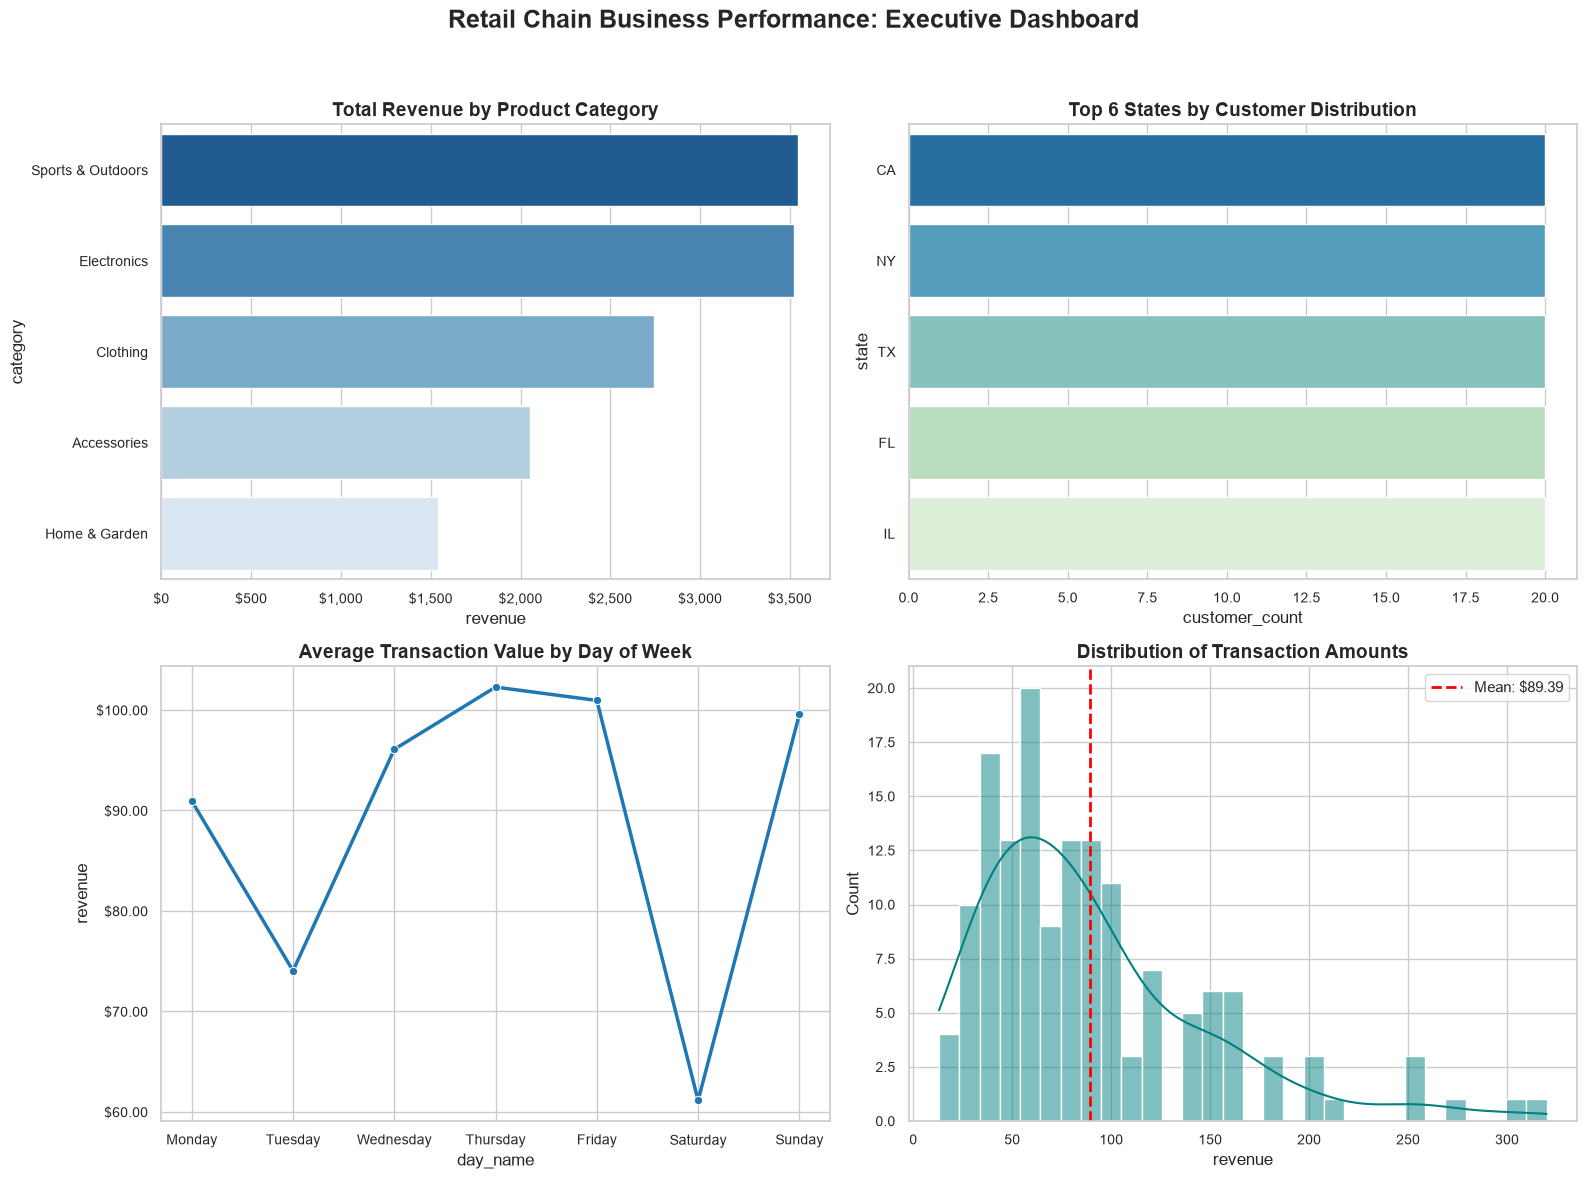

In [32]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 18
})
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retail Chain Business Performance: Executive Dashboard', fontweight='bold', y=0.98)


# Chart 1: Revenue by Product Category
rev_by_cat = df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(x='revenue', y='category', data=rev_by_cat, ax=axes[0, 0], palette='Blues_r', hue='category', legend=False)
axes[0, 0].set_title('Total Revenue by Product Category', fontweight='bold')
axes[0, 0].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Chart 2: Customer Distribution by State
top_states = customers['state'].value_counts().head(6).reset_index()
top_states.columns = ['state', 'customer_count']
sns.barplot(x='customer_count', y='state', data=top_states, ax=axes[0, 1], palette='GnBu_r', hue='state', legend=False)
axes[0, 1].set_title('Top 6 States by Customer Distribution', fontweight='bold')

# Chart 3: Daily Transaction Patterns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_name')['revenue'].mean().reindex(day_order).reset_index()
sns.lineplot(x='day_name', y='revenue', data=daily_avg, ax=axes[1, 0], marker='o', color='#1f77b4', linewidth=2.5)
axes[1, 0].set_title('Average Transaction Value by Day of Week', fontweight='bold')
axes[1, 0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.2f}'))

mean_val = df['revenue'].mean()
sns.histplot(df['revenue'], bins=30, ax=axes[1, 1], kde=True, color='teal')
axes[1, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:.2f}')
axes[1, 1].set_title('Distribution of Transaction Amounts', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('executive_dashboard.png', dpi=300)
plt.show()